# Florida roadway network (`rciroads`) — investigating `road-network fetch`

**Source.** `rciroads_jul26.shp` — FDOT RCI-derived roadway centerlines,
distributed through the Florida Geographic Data Library (FGDL). Fetched with
`python -m src.cli florida data road-network fetch` into
`data/florida/road_network/raw/`. Metadata:
<https://fgdl.org/zips/metadata/xml/rciroads_jul26.xml>. Full design brief:
[`docs/data/florida/road_network/README.md`](../../../docs/data/florida/road_network/README.md).

**Why this notebook.** `road_network` currently has only a `fetch` stage — no
`preprocess.py` yet. This notebook plays the role `barriers.ipynb` played
before `noise_barriers/preprocess.py` existed: it

1. loads the raw shapefile and documents its fields,
2. gives descriptive statistics (functional class, traffic volume, lane
   count, segment length, geometry) with a statewide map,
3. runs the data-quality checks the design brief's "Open questions" call for
   (milepost continuity, `DESCRIPT` content, CRS) — **resolving several of
   them**,
4. crystallizes what should move into `road_network/preprocess.py`.

**The school ↔ barrier matching-algorithm prototype (nearest-road spatial
join, linear referencing, side-of-centerline, the D/P sensitivity check)
lives in [`schools.ipynb`](schools.ipynb) §7** — it belongs there because it
consumes `schools/assemble.py`'s already-implemented point-only match as its
baseline, not because of anything specific to this notebook. Read this
notebook first for the network's own shape, then `schools.ipynb` §7 for how
it gets joined to schools and walls.

No pipeline module exists yet to import (unlike `assessments.ipynb` /
`schools.ipynb`), so this notebook re-implements the candidate logic — the
way `barriers.ipynb` did — pending it being lifted into `preprocess.py`.

**Note.** §2's descriptives are over raw `rciroads` segments (the roadway network itself) — that grain isn't part of the final panel (schools only inherit a same-route / same-side treatment flag from it), so it stays here rather than moving to [`descriptive_statistics.ipynb`](../../../output/notebooks/florida/descriptive_statistics.ipynb).

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

warnings.simplefilter("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110
BLUE, RED, GREEN, ORANGE, GREY = "#4C78A8", "#E45756", "#1f6f3f", "#d9822b", "#B0B0B0"


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.regions.florida.sources.road_network.shared import (              # noqa: E402
    DEFAULT_VERSION as RN_VERSION, raw_shapefile_path,
)

RN_SHP = raw_shapefile_path(RN_VERSION, ROOT)
FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)
assert RN_SHP.exists(), (
    f"{RN_SHP} missing — run `python -m src.cli florida data road-network fetch` first"
)

CRS_M = 3087          # Florida GDL Albers — metres, equal-area.
CRS_TILE = 3857        # Web-Mercator, for basemap tiles.
BASEMAP_LIGHT = cx.providers.Esri.WorldGrayCanvas


def add_basemap(ax, crs=CRS_M, source=BASEMAP_LIGHT, **kw):
    cx.add_basemap(ax, crs=crs, source=source, attribution_size=6, **kw)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("wrote", path.relative_to(ROOT))


def describe_num(s, name=""):
    s = pd.to_numeric(s, errors="coerce")
    q = s.quantile([0, .05, .5, .95, 1]).round(2)
    print(f"{name:28s} n={s.notna().sum():>7,}  nan={s.isna().sum():>6,}  "
          f"min={q[0]!s:>8}  p5={q[.05]!s:>8}  med={q[.5]!s:>8}  p95={q[.95]!s:>9}  max={q[1]!s:>10}")


ROOT, RN_SHP

(PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution'),
 PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/florida/road_network/raw/rciroads_jul26/rciroads_jul26.shp'))

## 1. Load & field dictionary

FGDL ships this release as a **Shapefile**, not a Geodatabase like
`noise_barriers` — confirmed while building `fetch` (see the README's
Open Question 1, resolved). `pyogrio` downgrades the raw `Measured
LineString` geometry type to plain `LineString`/`MultiLineString`, dropping
the `M` values — we don't use them (`BEGIN_POST`/`END_POST` carry the linear
reference as ordinary attributes instead), so the warning is silenced.

In [2]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")
    rn = gpd.read_file(RN_SHP)

print("rows:", len(rn), "| columns:", rn.shape[1])
print("CRS :", rn.crs.to_epsg(), "(", rn.crs.name, ")")
print("geometry types:", rn.geom_type.value_counts().to_dict())

xmin, ymin, xmax, ymax = rn.total_bounds
print(f"extent (m): x {xmin:,.0f}..{xmax:,.0f}  y {ymin:,.0f}..{ymax:,.0f}")
print("\nnull share by column:\n", rn.isna().mean().round(3))
rn.head(3)

rows: 40357 | columns: 17
CRS : 3087 ( NAD83(HARN) / Florida GDL Albers )
geometry types: {'LineString': 40320, 'MultiLineString': 37}
extent (m): x 57,645..793,919  y 62,549..781,514

null share by column:
 ROADWAY       0.0
BEGIN_POST    0.0
END_POST      0.0
YEAR_         0.0
AADT          0.0
FUNCLASSCO    0.0
FUNCLASS      0.0
LANE_CNT      0.0
SEGMENTID     0.0
DESCRIPT      0.0
FGDLAQDATE    0.0
RTLENGTH      0.0
RCILENGTH     0.0
ARCLENGTH     0.0
AUTOID        0.0
SHAPE_LEN     0.0
geometry      0.0
dtype: float64


,ROADWAY,BEGIN_POST,END_POST,YEAR_,AADT,FUNCLASSCO,FUNCLASS,LANE_CNT,SEGMENTID,DESCRIPT,FGDLAQDATE,RTLENGTH,RCILENGTH,ARCLENGTH,AUTOID,SHAPE_LEN,geometry
0,01000033,0.00,0.711,2025,3000,17,URBAN: Major Collector,2.0,46,URBAN: Major Collector,2026-07-10,0.711,0.711,0.71352,46,1149.313670,"LINESTRING (568310.321 326633.75, 568310.365 3..."
1,01000034,0.00,0.460,2025,10400,17,URBAN: Major Collector,4.0,47,URBAN: Major Collector,2026-07-10,0.460,0.460,0.46149,47,744.321244,"LINESTRING (564782.195 327040.479, 564787.663 ..."
2,01000034,0.46,0.506,2025,10400,17,URBAN: Major Collector,3.0,48,URBAN: Major Collector,2026-07-10,0.046,0.046,0.04614,48,74.422075,"LINESTRING (564779.843 327784.129, 564779.551 ..."


| field | type | meaning |
|---|---|---|
| `ROADWAY` | string(32) | FDOT's 8-digit-family roadway id — the RCI "route" this segment belongs to |
| `BEGIN_POST` / `END_POST` | double, miles | linear-reference milepost range along `ROADWAY` — enables algorithms 4/3 |
| `SEGMENTID` | int | segment id within the roadway; `(ROADWAY, SEGMENTID)` is unique (checked below) |
| `YEAR_` | int | data-currency year; mostly `2025`, `0` sentinel for ~16% of rows (checked below) |
| `FUNCLASSCO` / `FUNCLASS` | string / string | federal functional-classification code + label |
| `LANE_CNT` | double | lane count |
| `AADT` | int | annual average daily traffic — a head start for the future `traffic` source |
| `RTLENGTH` / `RCILENGTH` / `ARCLENGTH` / `SHAPE_LEN` | double | four length measures, metres — checked for consistency below |
| `DESCRIPT` | string | free text — **checked below: turns out to duplicate `FUNCLASS` exactly**, not a route name |
| `FGDLAQDATE` | date | FGDL acquisition date |
| `AUTOID` | int | internal row id |
| geometry | LineString / MultiLineString | centerline, EPSG:3087 |

No carriageway/direction/roadbed field — confirms the design decision already
on record in `docs/data/florida/schools/README.md`: side-of-road has to be
derived geometrically (§6 below), not read off an attribute.

## 2. Descriptive statistics

In [3]:
print("distinct ROADWAY ids:", rn["ROADWAY"].nunique(), "across", len(rn), "segments")
print("duplicate (ROADWAY, SEGMENTID) pairs:", rn.duplicated(["ROADWAY", "SEGMENTID"]).sum())

per_roadway = rn.groupby("ROADWAY").size()
print("\nsegments per ROADWAY:")
print(per_roadway.describe(percentiles=[.5, .9, .99]))
print(f"ROADWAY ids with >1 segment: {(per_roadway > 1).sum():,} of {len(per_roadway):,}")

distinct ROADWAY ids: 18373 across 40357 segments
duplicate (ROADWAY, SEGMENTID) pairs: 0

segments per ROADWAY:
count    18373.000000
mean         2.196538
std          3.330834
min          1.000000
50%          1.000000
90%          4.000000
99%         17.000000
max        111.000000
dtype: float64
ROADWAY ids with >1 segment: 6,425 of 18,373


wrote output/figures/florida/road_network_funclass_lanes.png


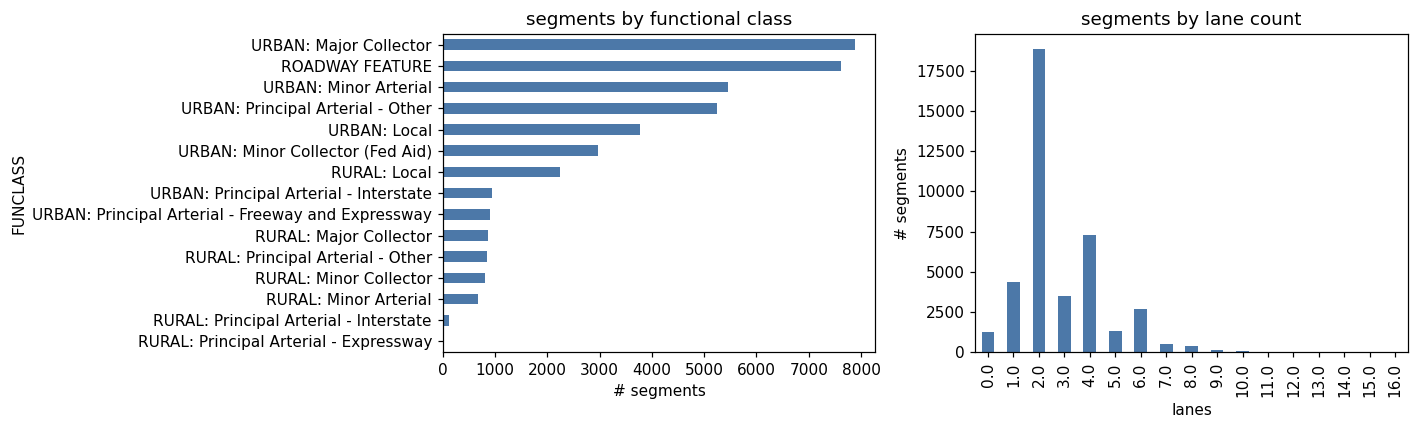

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rn["FUNCLASS"].value_counts().plot.barh(ax=axes[0], color=BLUE)
axes[0].invert_yaxis()
axes[0].set(title="segments by functional class", xlabel="# segments")

rn["LANE_CNT"].value_counts().sort_index().plot.bar(ax=axes[1], color=BLUE)
axes[1].set(title="segments by lane count", xlabel="lanes", ylabel="# segments")
fig.tight_layout()
savefig(fig, "road_network_funclass_lanes.png")

AADT                         n= 40,357  nan=     0  min=     0.0  p5=     0.0  med=  8200.0  p95=  56853.0  max=  336000.0
AADT == 0 share: 16.0%  (mostly local/unclassified roads, not a data gap)
LANE_CNT                     n= 40,357  nan=     0  min=     0.0  p5=     1.0  med=     2.0  p95=      6.0  max=      16.0


wrote output/figures/florida/road_network_aadt_hist.png


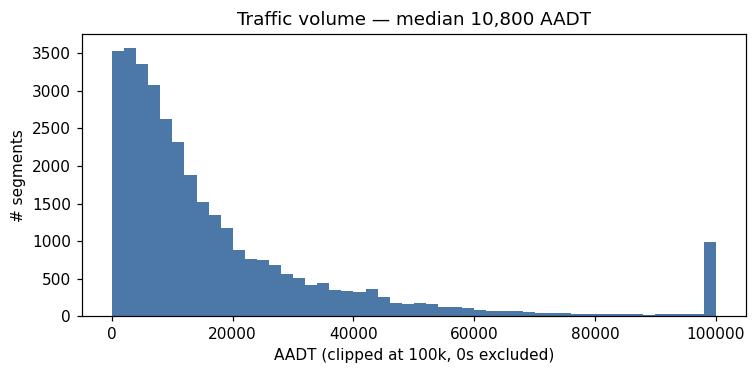

In [5]:
describe_num(rn["AADT"], "AADT")
print(f"AADT == 0 share: {(rn['AADT'] == 0).mean():.1%}  (mostly local/unclassified roads, not a data gap)")
describe_num(rn["LANE_CNT"], "LANE_CNT")

fig, ax = plt.subplots(figsize=(7, 3.5))
rn.loc[rn["AADT"] > 0, "AADT"].clip(upper=100_000).plot.hist(bins=50, ax=ax, color=BLUE)
ax.set(xlabel="AADT (clipped at 100k, 0s excluded)", ylabel="# segments",
       title=f"Traffic volume — median {rn.loc[rn['AADT'] > 0, 'AADT'].median():,.0f} AADT")
fig.tight_layout()
savefig(fig, "road_network_aadt_hist.png")

In [6]:
# YEAR_ sentinel share.
print("YEAR_ value counts:\n", rn["YEAR_"].value_counts())
print(f"\nYEAR_ == 0 (sentinel) share: {(rn['YEAR_'] == 0).mean():.1%}")

# Open Question 3 (README): does DESCRIPT carry a human-readable route name?
identical = (rn["DESCRIPT"] == rn["FUNCLASS"]).all()
print(f"\nDESCRIPT == FUNCLASS for every row: {identical}")
print("DESCRIPT is NOT a route name — it duplicates the functional-class label. "
      "Resolves Open Question 3: no human-readable route name exists in this layer; "
      "the spatial nearest-line join (§4) stays the right approach, not a name crosswalk.")

YEAR_ value counts:
 YEAR_
2025    33897
0        6460
Name: count, dtype: int64

YEAR_ == 0 (sentinel) share: 16.0%

DESCRIPT == FUNCLASS for every row: True
DESCRIPT is NOT a route name — it duplicates the functional-class label. Resolves Open Question 3: no human-readable route name exists in this layer; the spatial nearest-line join (§4) stays the right approach, not a name crosswalk.


In [7]:
# Length-field consistency: geometry length vs BEGIN_POST/END_POST (miles->m) vs the three RCI length fields.
rn["geom_len_m"] = rn.geometry.length
rn["post_len_m"] = (rn["END_POST"] - rn["BEGIN_POST"]).clip(lower=0) * 1609.344
ratio = rn["geom_len_m"] / rn["post_len_m"].replace(0, np.nan)
print("geometry length / (END_POST-BEGIN_POST in m) ratio:")
print(ratio.describe(percentiles=[.05, .5, .95]).round(4))
print("\n-> BEGIN_POST/END_POST reliably match the geometry's true length "
      "(median ratio ~1.000), confirming the linear reference is internally consistent.")

print("\ncorrelation with geometry length (m):")
for c in ("RTLENGTH", "RCILENGTH", "ARCLENGTH", "SHAPE_LEN"):
    print(f"  {c:12s} r={rn[c].corr(rn['geom_len_m']):.6f}")
print("ARCLENGTH / SHAPE_LEN are (near-)identical to the true geometry length; "
      "RTLENGTH/RCILENGTH correlate at r>0.998 but are a distinct (route-level?) measure.")

geometry length / (END_POST-BEGIN_POST in m) ratio:
count    40357.0000
mean         1.0004
std          0.0370
min          0.1113
5%           0.9874
50%          1.0002
95%          1.0139
max          4.4362
dtype: float64

-> BEGIN_POST/END_POST reliably match the geometry's true length (median ratio ~1.000), confirming the linear reference is internally consistent.

correlation with geometry length (m):
  RTLENGTH     r=0.998468
  RCILENGTH    r=0.998468
  ARCLENGTH    r=0.999998
  SHAPE_LEN    r=1.000000
ARCLENGTH / SHAPE_LEN are (near-)identical to the true geometry length; RTLENGTH/RCILENGTH correlate at r>0.998 but are a distinct (route-level?) measure.


## 3. Statewide map — major roads

Plotting all 40,357 segments is possible but not informative at statewide
zoom; barriers sit on state highways, so restrict to the
`Principal Arterial` classes (interstates, freeways/expressways, other
principal arterials) — 8,082 segments, roughly the population `noise_barriers`
walls actually abut.

wrote output/figures/florida/road_network_statewide_major.png


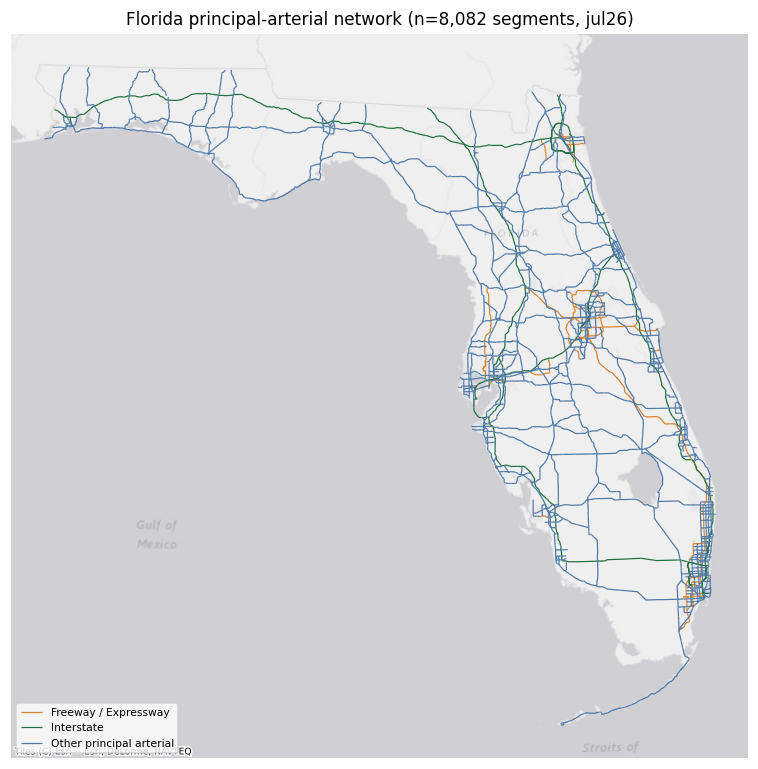

In [8]:
major = rn[rn["FUNCLASS"].str.contains("Principal Arterial")]
# Urban/rural variants of the same tier share a color and a legend entry
# (their raw labels differ slightly: "Freeway and Expressway" vs "Expressway").
tier_color = {
    "URBAN: Principal Arterial - Interstate": ("Interstate", "#1f6f3f"),
    "RURAL: Principal Arterial - Interstate": ("Interstate", "#1f6f3f"),
    "URBAN: Principal Arterial - Freeway and Expressway": ("Freeway / Expressway", ORANGE),
    "RURAL: Principal Arterial - Expressway": ("Freeway / Expressway", ORANGE),
    "URBAN: Principal Arterial - Other": ("Other principal arterial", BLUE),
    "RURAL: Principal Arterial - Other": ("Other principal arterial", BLUE),
}

fig, ax = plt.subplots(figsize=(7, 9))
seen_labels = set()
for cls, sub in major.groupby("FUNCLASS"):
    label, color = tier_color.get(cls, (cls, "#333"))
    sub.plot(ax=ax, color=color, linewidth=0.8, label=None if label in seen_labels else label)
    seen_labels.add(label)
add_basemap(ax, source=BASEMAP_LIGHT)
ax.set_axis_off()
ax.legend(loc="lower left", fontsize=7, frameon=True)
ax.set_title(f"Florida principal-arterial network (n={len(major):,} segments, {RN_VERSION})", fontsize=11)
fig.tight_layout()
savefig(fig, "road_network_statewide_major.png")

## 4. Data-quality check: milepost continuity (Open Question 5)

RCI mileposts can in principle reset at county lines or route breaks, which
would let a naive `±D` milepost tolerance in algorithm 4 silently bridge two
unrelated stretches of the same `ROADWAY` id. Check the gap between
consecutive segments (sorted by `BEGIN_POST`) within each `ROADWAY`.

In [9]:
g = rn.sort_values(["ROADWAY", "BEGIN_POST"])
gap_series = g.groupby("ROADWAY").apply(
    lambda d: pd.Series(d["BEGIN_POST"].to_numpy()[1:] - d["END_POST"].to_numpy()[:-1], index=d.index[1:])
)
gaps = gap_series.reset_index(level=0)[0] if len(gap_series) else pd.Series(dtype=float)

print(f"ROADWAY ids with >1 segment: {(per_roadway > 1).sum():,}  |  consecutive-segment gaps checked: {len(gaps):,}")
print(gaps.describe(percentiles=[.01, .5, .95, .99]).round(4))
print(f"\nshare |gap| > 0.05 mi (~80 m): {(gaps.abs() > 0.05).mean():.4%}")
print(f"share |gap| > 1 mi (possible reset/break): {(gaps.abs() > 1).mean():.4%}  "
      f"(n={int((gaps.abs() > 1).sum())})")

outlier_roadway = gaps.reset_index()
big = gaps[gaps.abs() > 1]
print("\nthe one outlier:")
print(rn.loc[rn["ROADWAY"] == g.loc[big.index[0], "ROADWAY"], ["ROADWAY", "SEGMENTID", "BEGIN_POST", "END_POST"]]
      if len(big) else "none")

ROADWAY ids with >1 segment: 6,425  |  consecutive-segment gaps checked: 21,984
count    21984.0000
mean        -0.0002
std          0.0294
min         -4.3600
1%           0.0000
50%          0.0000
95%          0.0000
99%          0.0000
max          0.0010
Name: 0, dtype: float64

share |gap| > 0.05 mi (~80 m): 0.0045%
share |gap| > 1 mi (possible reset/break): 0.0045%  (n=1)

the one outlier:
       ROADWAY  SEGMENTID  BEGIN_POST  END_POST
9613  14121000       7416         0.0      4.36
9614  14121000       7417         0.0      4.36


**Resolves Open Question 5 (mostly).** 99% of consecutive same-`ROADWAY`
segment pairs have essentially zero milepost gap (median 0.000 mi) — the
linear reference is seamless almost everywhere, so a small `±D` tolerance
(e.g. 0.1–0.2 mi, calibrated in §6) will not silently bridge unrelated
stretches for the overwhelming majority of roads. There is exactly **one**
outlier (`ROADWAY 14121000`, a −4.36 mi overlap, not a gap) — worth a
targeted check if that specific roadway ever matters for a school/wall pair,
but not worth a general defensive mechanism. The already-recommended
geometric sanity guard (require the matched school/wall to also be close in
straight-line distance, not just milepost) catches this class of error for
free regardless.

## Notes & next steps

**Resolved open questions (road_network README):**

- **Q1 (archive layout):** `rciroads_<version>.zip` is a zipped **Shapefile**,
  not a Geodatabase — confirmed for `jul26` and the oldest archived release
  (`jun04`); `fetch.py` already handles this (`_find_shapefile_members`).
- **Q2 (CRS):** EPSG:3087, same as `noise_barriers` — no reprojection needed.
- **Q3 (`DESCRIPT`):** duplicates `FUNCLASS` exactly — **not** a route name.
  The school ↔ barrier join stays a spatial nearest-line join, not a name
  crosswalk (see `schools.ipynb` §7).
- **Q5 (milepost discontinuities):** 99% of consecutive same-`ROADWAY`
  segment pairs have ~zero milepost gap; one outlier (`ROADWAY 14121000`).

**Q6 (validation against real barriers) and the matching-algorithm
prototype (3–5) — moved to [`schools.ipynb`](schools.ipynb) §7**, since they
consume `schools/assemble.py`'s point-only match as a baseline and belong
next to it rather than here.

**What should move into `road_network/preprocess.py`:** tidy column set
(`roadway_id`, `segmentid`, `begin_post`, `end_post`, `funclass`, `aadt`,
`lane_cnt`, `geometry`), `MultiLineString` flattening (37 of 40,357 segments
are non-contiguous multi-part geometries that break `shapely`'s
`.project()`/`.interpolate()` — pre-flatten once here rather than handling it
per lookup downstream), EPSG:3087 passthrough (already native), a provenance
sidecar (mirror `barriers.json`) — no cleaning rules were needed beyond that
(no nulls, no sentinel row-drops the way `noise_barriers`' `TYPE` filter
needed).